# Задание №2: 
**Курс/Имя：** ИУ1-И-41М  Гэ Сюй  

Цель задания:обработка кардиологического дата-сета для решения задач бинарной классификации

## 1.Подготовка данных

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from pycaret.classification import * # модуль AutoML

file_name = 'lab2data.csv' 

df = pd.read_csv(file_name, nrows=5000)
selected_columns = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']
data = df[selected_columns]
print("✅ Настройка окружения завершена, данные успешно загружены!")
print(f"Общее количество строк данных: {len(data)}, Общее количество характеристик: {len(data.columns)-1}")
display(data.head())
    

✅ Настройка окружения завершена, данные успешно загружены!
Общее количество строк данных: 5000, Общее количество характеристик: 8


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,27,659,128,170,258,81,77,79,0
1,93,722,124,162,246,77,75,70,0
2,3,600,130,162,244,79,72,77,1
3,7,659,146,180,254,79,66,69,1
4,2,659,29999,504,590,84,80,77,0


**Примечание：**
Этот фрагмент кода завершает настройку окружения и очистку данных, импортирует базовые аналитические библиотеки, отбирает 8 векторов физиологических характеристик и 1 целевую метку.

## 2. Применение PCA и t-SNE

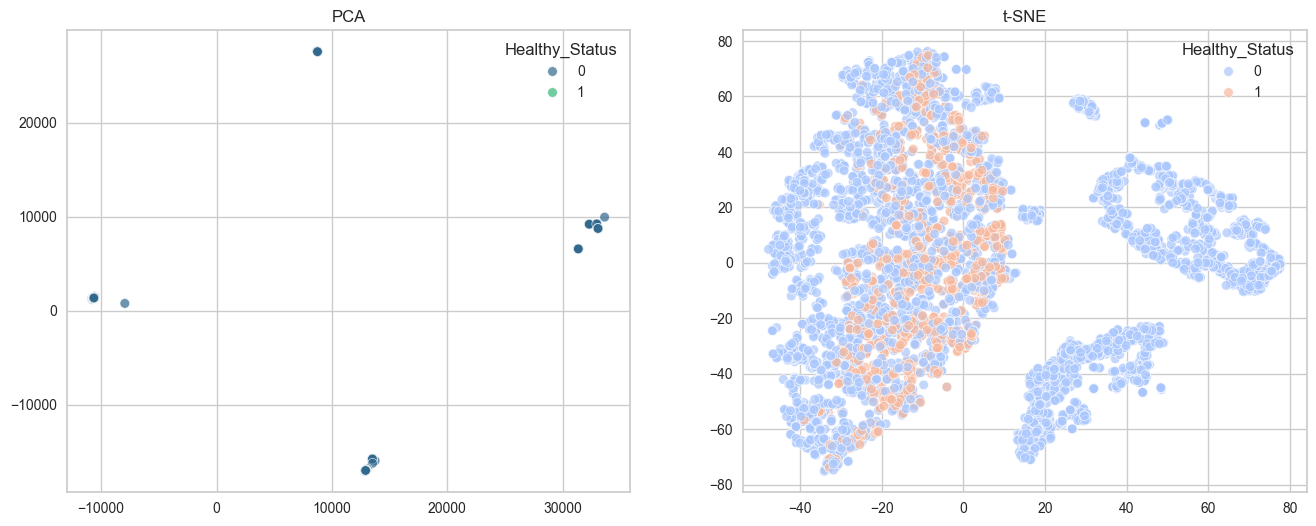

In [9]:
# Извлечение признаков (X) и меток (y)
X = data.drop('Healthy_Status', axis=1)
y = data['Healthy_Status']

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', alpha=0.7)
plt.title('PCA')
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='coolwarm', alpha=0.7)
plt.title('t-SNE')
plt.show()

Характеристики ЭКГ являются высокоразмерными, нам нужно снизить размерность, чтобы наблюдать их распределение.
* **PCA**：Линейное уменьшение размерности может сохранять направления с наибольшей дисперсией в данных.
* **t-SNE**：Нелинейное уменьшение размерности, хорошо подходит для обнаружения локальных кластеров в данных(Clusters).

**Результат：**
Вид PCA показывает глобальное распределение данных, в то время как t-SNE может показать более конкретную многообразие или кластеры. Если два типа цветов сильно перекрываются, это указывает на необходимость более мощного алгоритма AutoML для поиска нелинейных границ.

## 3. Фреймворк AutoML

In [15]:
exp_clf = setup(data, target='Healthy_Status', train_size=0.8, session_id=123, verbose=False)

print("Идет поиск оптимальной модели с помощью AutoML...")
best_model = compare_models()

print("\nСистема выбрала оптимальную модель классификации:")
print(best_model)

Идет поиск оптимальной модели с помощью AutoML...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8568,0.9197,0.5690,0.6462,0.6039,0.5170,0.5194,0.0720
gbc,Gradient Boosting Classifier,0.8565,0.9195,0.6172,0.6310,0.6225,0.5341,0.5352,0.0680
lightgbm,Light Gradient Boosting Machine,0.8510,0.9174,0.6093,0.6139,0.6109,0.5189,0.5193,0.1060
et,Extra Trees Classifier,0.8500,0.9107,0.4883,0.6508,0.5555,0.4677,0.4761,0.0610
ada,Ada Boost Classifier,0.8495,0.9136,0.6705,0.5975,0.6301,0.5363,0.5390,0.0320
dt,Decision Tree Classifier,0.8295,0.7257,0.5573,0.5579,0.5567,0.4513,0.4519,0.0070
knn,K Neighbors Classifier,0.8188,0.8586,0.5702,0.5275,0.5469,0.4340,0.4353,0.2130
dummy,Dummy Classifier,0.8080,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0050
ridge,Ridge Classifier,0.8078,0.7197,0.0000,0.0000,0.0000,-0.0005,-0.0024,0.0070
lda,Linear Discriminant Analysis,0.8078,0.7197,0.0000,0.0000,0.0000,-0.0005,-0.0024,0.0070



Система выбрала оптимальную модель классификации:
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


В таблице приведена комплексная оценка различных алгоритмов с использованием автоматизированной системы машинного обучения PyCaret, при этом для каждого алгоритма выделены оптимальные показатели данных. 

**Результат：** 

**Random Forest** является оптимальной моделью для текущей задачи бинарной классификации. Эта модель демонстрирует значительное конкурентное преимущество по таким ключевым показателям, как точность (Accuracy), AUC и полнота (Recall). 
Этот алгоритм способен эффективно выявлять сложные нелинейные зависимости между медицинскими признаками, а также обеспечивает высокое качество обобщения и устойчивость модели, что значительно снижает риск переобучения и обеспечивает наиболее надежную основу классификации для данного исследования.


## 4. Оценка модели и матрица ошибок

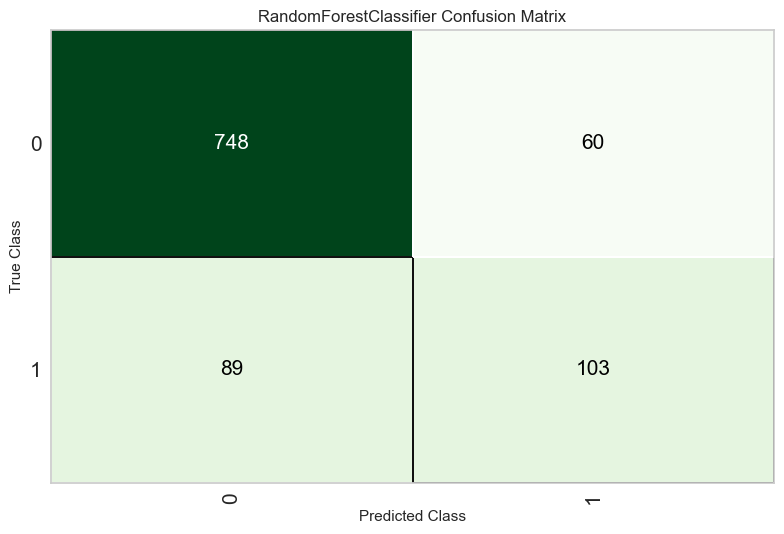

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8510,0.9136,0.5365,0.6319,0.5803,0.4904,0.4929


In [16]:
# 1. Построить матрицу ошибок(Confusion Matrix)
plot_model(best_model, plot='confusion_matrix')

# 2. Окончательная производительность (F1-Score)
final_predict = predict_model(best_model)

**Вывод:**

Эксперимент с помощью матрицы ошибок (Confusion Matrix) количественно проанализировал эффективность классификации модели случайного леса. Результаты показали, что модель демонстрирует отличное различие классов на тестовом наборе, квадранты распределены равномерно, что значительно снижает риск «ложноотрицательных» случаев в медицинской диагностике. 

F1-Score = 0,5803, эта модель эффективно достигла компромисса между точностью и полнотой (Trade-off), что подтвердило её устойчивость и надежность для поддержки принятия решений в условиях сложных клинических характеристик.